In [1]:
# Mount Drive + cài thư viện
from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers datasets accelerate tensorboard
!pip install -q evaluate scikit-learn albumentations

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.4 MB/s eta 0:00:00


In [ ]:
import os
import glob
import json
import random
import time
from collections import Counter
from pathlib import Path

import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from scipy.special import softmax as scipy_softmax

import evaluate
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
)
from torchvision.transforms import (
    ColorJitter, Compose, GaussianBlur, RandomAdjustSharpness,
)
from transformers import (
    DefaultDataCollator,
    LayoutLMv3ForSequenceClassification,
    LayoutLMv3Processor,
    Trainer,
    TrainingArguments,
)

from transformers.trainer_utils import get_last_checkpoint

matplotlib.rcParams["figure.dpi"] = 120

In [ ]:
# Cố định ngẫu nhiên (seed) và khai báo đường dẫn

SEED = 42
DRIVE_ROOT = "/content/drive/MyDrive/Document_AI"
IMAGE_DIR   = "/content/Document_AI_Project/data/data_subset"


# Đường dẫn file metadata
TRAIN_JSONL = f"{DRIVE_ROOT}/dataset/train_metadata.jsonl"
VAL_JSONL   = f"{DRIVE_ROOT}/dataset/val_metadata.jsonl"
TEST_JSONL  = f"{DRIVE_ROOT}/dataset/test_metadata.jsonl"

# Thư mục output
OUT_MAIN  = f"{DRIVE_ROOT}/outputs"
OUT_EXP   = f"{DRIVE_ROOT}/experiments"
OUT_EVAL  = f"{DRIVE_ROOT}/eval"
for d in [OUT_MAIN, OUT_EXP, OUT_EVAL]:
    os.makedirs(d, exist_ok=True)



def seed_everything(seed: int = SEED):
    """Cố định toàn bộ nguồn ngẫu nhiên để kết quả tái lập được."""
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed) # Cố định random của PyTorch trên CPU (Ảnh hưởng tới: khởi tạo weight, dropout, random tensor, shuffle.)
    torch.backends.cudnn.benchmark = False

seed_everything()


In [ ]:
# Giải nén tập ảnh từ Drive vào Colab local

%cd /content
!mkdir -p Document_AI_Project
!unzip -q "{DRIVE_ROOT}/dataset/data_subset.zip" -d /content/Document_AI_Project/data
print("Giải nén xong: ", IMAGE_DIR)


/content
Giải nén xong:  /content/Document_AI_Project/data/data_subset


In [ ]:
# Khai báo bảng nhãn (16 lớp – RVL-CDIP)
CLASS_TO_IDX = {
    "letter": 0,        "form": 1,          "email": 2,
    "handwritten": 3,   "advertisement": 4, "scientific_report": 5,
    "scientific_publication": 6,            "specification": 7,
    "file_folder": 8,   "news_article": 9,  "budget": 10,
    "invoice": 11,      "presentation": 12, "questionnaire": 13,
    "resume": 14,       "memo": 15,
}

# Danh sách nhãn theo thứ tự index (dùng cho sklearn và Trainer)
LABEL_LIST = [name for name, _ in sorted(CLASS_TO_IDX.items(), key=lambda x: x[1])]
ID2LABEL   = {i: name for i, name in enumerate(LABEL_LIST)}
LABEL2ID   = {name: i  for i, name in enumerate(LABEL_LIST)}
NUM_LABELS = len(LABEL_LIST)

print(f"{NUM_LABELS} nhãn:")
for i, name in ID2LABEL.items():
    print(f"   {i:>2}: {name}")

16 nhãn:
    0: letter
    1: form
    2: email
    3: handwritten
    4: advertisement
    5: scientific_report
    6: scientific_publication
    7: specification
    8: file_folder
    9: news_article
   10: budget
   11: invoice
   12: presentation
   13: questionnaire
   14: resume
   15: memo


In [ ]:
# Đọc file JSONL và tạo HuggingFace Dataset
# Cấu trúc mỗi dòng JSONL: { "file_name": "...", "words": [...], "bboxes": [[x0,y0,x1,y1], ...], "label": 0 }

def data_generator(jsonl_path: str):
    """Generator đọc từng dòng JSONL, bỏ qua mẫu không tìm thấy ảnh."""
    with open(jsonl_path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            item = json.loads(line)
            img_path = os.path.join(IMAGE_DIR, item["file_name"])
            if not os.path.exists(img_path):
                continue
            label = item["label"]
            yield {
                "image":  img_path,
                "tokens": item["words"],
                "bboxes": item["bboxes"],
                "label":  int(label[0] if isinstance(label, list) else label),
            }

train_ds = Dataset.from_generator(data_generator, gen_kwargs={"jsonl_path": TRAIN_JSONL})
val_ds   = Dataset.from_generator(data_generator, gen_kwargs={"jsonl_path": VAL_JSONL})
test_ds  = Dataset.from_generator(data_generator, gen_kwargs={"jsonl_path": TEST_JSONL})

print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}")

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Train: 31,929 | Val: 3,991 | Test: 3,993


In [ ]:
# Khởi tạo Processor và định nghĩa Transform
# LayoutLMv3Processor = ViTFeatureExtractor (ảnh) + RoBERTa Tokenizer (text)
# apply_ocr=False vì đã có token + bbox từ JSONL (không cần chạy OCR lại)


processor = LayoutLMv3Processor.from_pretrained(
    "microsoft/layoutlmv3-base",
    apply_ocr=False,
)

# ── Augmentation chỉ áp dụng cho tập Train ─────────────────────────────────
# Chỉ dùng biến đổi màu sắc/pixel, KHÔNG dùng flip/crop/rotate
# (lý do: bbox sẽ bị lệch nếu ảnh bị cắt hay xoay)
_train_augment = Compose([
    ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2), # Thay đổi ánh sáng/độ tương phản
    GaussianBlur(kernel_size=(5, 5), sigma=(0.1, 2.0)), # Làm mờ chữ giống scan chất lượng kém
    RandomAdjustSharpness(sharpness_factor=2, p=0.5), # Tăng độ sắc nét ngẫu nhiên
])


def _encode(examples, augment: bool = False):
    """Hàm nội bộ: mã hoá batch ảnh + text → tensor cho Trainer."""
    images = [Image.open(p).convert("RGB") for p in examples["image"]]
    if augment:
        images = [_train_augment(img) for img in images]

    #Đưa vào Processor
    enc = processor(
        images,
        examples["tokens"],
        boxes=examples["bboxes"],
        max_length=512,
        padding="max_length",
        truncation=True,
    )
    enc["labels"] = torch.tensor(examples["label"], dtype=torch.long)
    return enc


def train_transforms(examples):
    return _encode(examples, augment=True)

def eval_transforms(examples):
    return _encode(examples, augment=False)

# Kích hoạt Online Transform cho Dataset
train_ds.set_transform(train_transforms)
val_ds.set_transform(eval_transforms)
test_ds.set_transform(eval_transforms)
print("Processor và transform đã gán cho 3 tập dữ liệu")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

The image processor of type `LayoutLMv3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Processor và transform đã gán cho 3 tập dữ liệu


In [ ]:
# Training
"""
**Chiến lược lưu checkpoint** (tránh mất tiến trình khi hết giờ Colab):
- Cuối mỗi epoch → ghi đè `outputs/checkpoint-*` lên Drive
- Epoch tốt nhất (Macro F1 cao nhất) → `load_best_model_at_end=True`
- Khi mở lại Colab → Code chạy, tự tìm checkpoint mới nhất để tiếp tục
"""


# Hàm tính metric cho Trainer

_accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = _accuracy.compute(predictions=preds, references=labels)["accuracy"]
    macro_f1  = f1_score(labels, preds, average="macro",  zero_division=0)
    precision = precision_score(labels, preds, average="macro", zero_division=0)
    recall    = recall_score(labels, preds, average="macro",    zero_division=0)
    return {
        "accuracy":  round(acc,       4),
        "f1":        round(macro_f1,  4),   # Trainer dùng "f1" để chọn best model
        "precision": round(precision, 4),
        "recall":    round(recall,    4),
    }
print("compute_metrics đã cập nhật (Acc + Macro F1 + P + R)")

compute_metrics đã cập nhật (Acc + Macro F1 + P + R)


In [ ]:
# Load model LayoutLMv3 từ pretrained

model = LayoutLMv3ForSequenceClassification.from_pretrained(
    "microsoft/layoutlmv3-base",
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)


total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model: {model.config.model_type} | {total_params:.1f}M params")

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

LayoutLMv3ForSequenceClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                                | Status     | 
-----------------------------------+------------+-
layoutlmv3.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias              | MISSING    | 
classifier.out_proj.bias           | MISSING    | 
classifier.out_proj.weight         | MISSING    | 
classifier.dense.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: layoutlmv3 | 125.9M params


In [ ]:
# Cấu hình huấn luyện, khởi tạo Trainer và chạy train
# Hyperparameter đã chọn:
#   lr=2e-5   : an toàn cho attention weights của Transformer
#   warmup=10%: học rate tăng dần → tránh vỡ gradient đầu epoch
#   wd=0.01 (weight decay)  : L2 regularization → giảm overfitting


# 🎯 THAY THẾ TOÀN BỘ Ô CODE SỐ 10
training_args = TrainingArguments(
    # Sửa đường dẫn
    output_dir                  = "/content/drive/MyDrive/Document_AI/checkpoints/outputs_tinh_chinh",
    logging_dir                 = "/content/drive/MyDrive/Document_AI/checkpoints/outputs_tinh_chinh/logs",

    # Rút ngắn xuống đúng 3 Epoch (Vì từ epoch 2-3 mô hình đã đạt đỉnh, train tiếp sẽ overfit)
    num_train_epochs            = 3,

    per_device_train_batch_size = 4,
    gradient_accumulation_steps = 2,
    learning_rate               = 2e-5,
    warmup_ratio                = 0.1,

    # Tăng mạnh Weight Decay để phạt nặng hành vi học vẹt dữ liệu
    weight_decay                = 0.05,

    fp16                        = True,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    logging_steps               = 50,
    save_total_limit            = 2,
    load_best_model_at_end      = True,

    # Khóa cứng việc chọn bộ não dựa trên điểm F1 cao nhất tập Val
    metric_for_best_model       = "f1",
    greater_is_better           = True,
    remove_unused_columns       = False,
    report_to                   = "tensorboard",
)

# Bơm thêm tỷ lệ Dropout 20% vào cấu trúc cấu trúc mạng mạng để ép mô hình học tổng quát
model.config.attention_probs_dropout_prob = 0.2
model.config.hidden_dropout_prob = 0.2

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    data_collator   = DefaultDataCollator(),
    compute_metrics = compute_metrics,
)
print("🎯 Đã cấu hình bộ tham số tinh chỉnh độc lập")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


🎯 Đã cấu hình bộ tham số tinh chỉnh độc lập


In [ ]:

# ── Tự động tiếp tục từ checkpoint nếu có ──────────────────────────────────

from transformers.trainer_utils import get_last_checkpoint

# Tự động quét xem trong folder độc lập đã có checkpoint nào chạy dở chưa
last_checkpoint = get_last_checkpoint("/content/drive/MyDrive/Document_AI/checkpoints/outputs_tinh_chinh")

if last_checkpoint is not None:
    print(f"▶ Phát hiện sự cố ngắt kết nối! Tự động tiếp tục training từ checkpoint cũ: {last_checkpoint}")
    # Đổi tài khoản hoặc sập mạng chỉ cần bấm Play lại, máy sẽ chạy tiếp từ Epoch bị dừng dở
    trainer.train(resume_from_checkpoint=last_checkpoint)
else:
    print("▶ Thư mục trống sạch sẽ. Bắt đầu huấn luyện lại từ đầu (Epoch 1/3)...")
    trainer.train()


▶ Phát hiện sự cố ngắt kết nối! Tự động tiếp tục training từ checkpoint cũ: /content/drive/MyDrive/Document_AI/checkpoints/outputs_tinh_chinh/checkpoint-3992


There were missing keys in the checkpoint model loaded: ['layoutlmv3.embeddings.LayerNorm.weight', 'layoutlmv3.embeddings.LayerNorm.bias', 'layoutlmv3.LayerNorm.weight', 'layoutlmv3.LayerNorm.bias', 'layoutlmv3.encoder.layer.0.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.0.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.0.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.0.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.1.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.1.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.1.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.1.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.2.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.2.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.2.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.2.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.3.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.3.attention.out

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
2,0.733018,0.388792,0.923100,0.923000,0.924500,0.923100
3,0.553825,0.377865,0.930300,0.930200,0.930400,0.930400


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['layoutlmv3.embeddings.LayerNorm.weight', 'layoutlmv3.embeddings.LayerNorm.bias', 'layoutlmv3.LayerNorm.weight', 'layoutlmv3.LayerNorm.bias', 'layoutlmv3.encoder.layer.0.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.0.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.0.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.0.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.1.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.1.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.1.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.1.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.2.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.2.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.2.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.2.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.3.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.3.attention.out

In [ ]:
import os
import json
import torch
import torch.nn as nn
import pandas as pd
from PIL import Image
from torch.utils.data import DataLoader, Dataset as TorchDataset
from torchvision import models, transforms
from transformers import BertModel, BertTokenizer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm.notebook import tqdm

print("🚀 Khởi động luồng đánh giá tập Test chuẩn cấu trúc thư mục phân cấp...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DRIVE_ROOT_REAL = '/content/drive/MyDrive/LayoutLM_Project'
PROCESSED_DATA_REAL = f'{DRIVE_ROOT_REAL}/processed_data'
CHECKPOINT_DIR_REAL = f'{DRIVE_ROOT_REAL}/checkpoints'

# Thư mục cha (chứa folder 'test' bên trong)
RESNET_BASE_IMG_DIR = '/content/resnet_images/resnet_images'

def calculate_metrics(all_labels, all_preds):
    return {
        "Accuracy": round(accuracy_score(all_labels, all_preds), 4),
        "Macro_F1": round(f1_score(all_labels, all_preds, average='macro', zero_division=0), 4),
        "Precision": round(precision_score(all_labels, all_preds, average='macro', zero_division=0), 4),
        "Recall": round(recall_score(all_labels, all_preds, average='macro', zero_division=0), 4)
    }

# ══════════════════════════════════════════════════════════════════════════
# 🖼️ PHẦN 1: ĐÁNH GIÁ RESNET50 (ĂN KHỚP THEO ĐƯỜNG DẪN PHÂN CẤP)
# ══════════════════════════════════════════════════════════════════════════
print("\n🖼️ Đang bốc bộ não ResNet50_best từ Drive và chạy Test...")

class ResNetTestDataset(TorchDataset):
    def __init__(self, jsonl_path, base_dir, transform):
        self.samples = []
        self.base_dir = base_dir
        self.transform = transform

        # Tự động bắt phím chứa đường dẫn phân cấp (resnet_image_path)
        with open(jsonl_path, encoding="utf-8") as f:
            for line in f:
                first_item = json.loads(line)
                possible_keys = ['resnet_image_path', 'file_name', 'image', 'path']
                self.img_key = next((k for k in possible_keys if k in first_item), list(first_item.keys())[0])
                break

        with open(jsonl_path, encoding="utf-8") as f:
            for line in f:
                item = json.loads(line)
                # Giữ nguyên cấu trúc "test/advertisement/00001014.jpg"
                relative_path = str(item[self.img_key])
                self.samples.append((relative_path, int(item["label"])))

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        rel_path, label = self.samples[idx]

        # Nối chuẩn: /content/resnet_images/resnet_images/ + test/advertisement/00001014.jpg
        img_path = os.path.join(self.base_dir, rel_path)

        img = Image.open(img_path).convert("RGB")
        return self.transform(img), label

resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

resnet_model = models.resnet50()
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 16)
resnet_checkpoint = torch.load(f"{CHECKPOINT_DIR_REAL}/resnet50_best.pt", map_location=device)
resnet_model.load_state_dict(resnet_checkpoint['model_state_dict'])
resnet_model = resnet_model.to(device).eval()

resnet_dataset = ResNetTestDataset(f"{PROCESSED_DATA_REAL}/resnet_test.jsonl", RESNET_BASE_IMG_DIR, resnet_transform)
resnet_loader = DataLoader(resnet_dataset, batch_size=32, shuffle=False)

resnet_preds, resnet_labels = [], []
with torch.no_grad():
    for imgs, lbls in tqdm(resnet_loader, desc="ResNet50 Testing"):
        outputs = resnet_model(imgs.to(device))
        resnet_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        resnet_labels.extend(lbls.numpy())
resnet_results = calculate_metrics(resnet_labels, resnet_preds)


# ══════════════════════════════════════════════════════════════════════════
# 📝 PHẦN 2: ĐÁNH GIÁ BERT (TEXT ONLY)
# ══════════════════════════════════════════════════════════════════════════
print("\n📝 Đang bốc bộ não BERT_best từ Drive và chạy Test...")

class BERTClassifier(nn.Module):
    def __init__(self, num_classes=16):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.classifier = nn.Linear(768, num_classes)
    def forward(self, input_ids, attention_mask, token_type_ids):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        return self.classifier(outputs.pooler_output)

class BERTTestDataset(TorchDataset):
    def __init__(self, jsonl_path, tokenizer, max_len=512):
        self.samples = []
        self.tokenizer = tokenizer
        self.max_len = max_len
        with open(jsonl_path, encoding="utf-8") as f:
            for line in f:
                item = json.loads(line)
                self.samples.append((item["text"], int(item["label"])))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        text, label = self.samples[idx]
        encoding = self.tokenizer(text, max_length=self.max_len, padding="max_length", truncation=True, return_tensors="pt")
        return {k: v.squeeze(0) for k, v in encoding.items()}, label

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BERTClassifier()
bert_checkpoint = torch.load(f"{CHECKPOINT_DIR_REAL}/bert_best.pt", map_location=device)
bert_model.load_state_dict(bert_checkpoint['model_state_dict'])
bert_model = bert_model.to(device).eval()

bert_dataset = BERTTestDataset(f"{PROCESSED_DATA_REAL}/bert_test.jsonl", tokenizer)
bert_loader = DataLoader(bert_dataset, batch_size=16, shuffle=False)

bert_preds, bert_labels = [], []
with torch.no_grad():
    for batch, lbls in tqdm(bert_loader, desc="BERT Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        outputs = bert_model(input_ids, attention_mask, token_type_ids)
        bert_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        bert_labels.extend(lbls.numpy())
bert_results = calculate_metrics(bert_labels, bert_preds)


# ══════════════════════════════════════════════════════════════════════════
# 📊 PHẦN 3: IN BẢNG KẾT QUẢ ĐỐI CHỨNG
# ══════════════════════════════════════════════════════════════════════════
summary_data = {
    "Mô hình (Model)": ["ResNet50 (Chỉ dùng Ảnh)", "BERT (Chỉ dùng Chữ)"],
    "Accuracy": [resnet_results["Accuracy"], bert_results["Accuracy"]],
    "Macro F1-Score": [resnet_results["Macro_F1"], bert_results["Macro_F1"]],
    "Precision": [resnet_results["Precision"], bert_results["Precision"]],
    "Recall": [resnet_results["Recall"], bert_results["Recall"]]
}

df_res = pd.DataFrame(summary_data)
print("\n==================================================================")
print("🎉 KẾT QUẢ ĐÁNH GIÁ THỰC NGHIỆM TRÊN TẬP TEST ĐỘC LẬP ")
print("==================================================================")
display(df_res)

🚀 Khởi động luồng đánh giá tập Test chuẩn cấu trúc thư mục phân cấp...

🖼️ Đang bốc bộ não ResNet50_best từ Drive và chạy Test...


ResNet50 Testing:   0%|          | 0/125 [00:00<?, ?it/s]


📝 Đang bốc bộ não BERT_best từ Drive và chạy Test...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT Testing:   0%|          | 0/250 [00:00<?, ?it/s]


🎉 KẾT QUẢ ĐÁNH GIÁ THỰC NGHIỆM TRÊN TẬP TEST ĐỘC LẬP 


,Mô hình (Model),Accuracy,Macro F1-Score,Precision,Recall
0,ResNet50 (Chỉ dùng Ảnh),0.8452,0.8465,0.8488,0.8454
1,BERT (Chỉ dùng Chữ),0.8790,0.8793,0.8820,0.8791


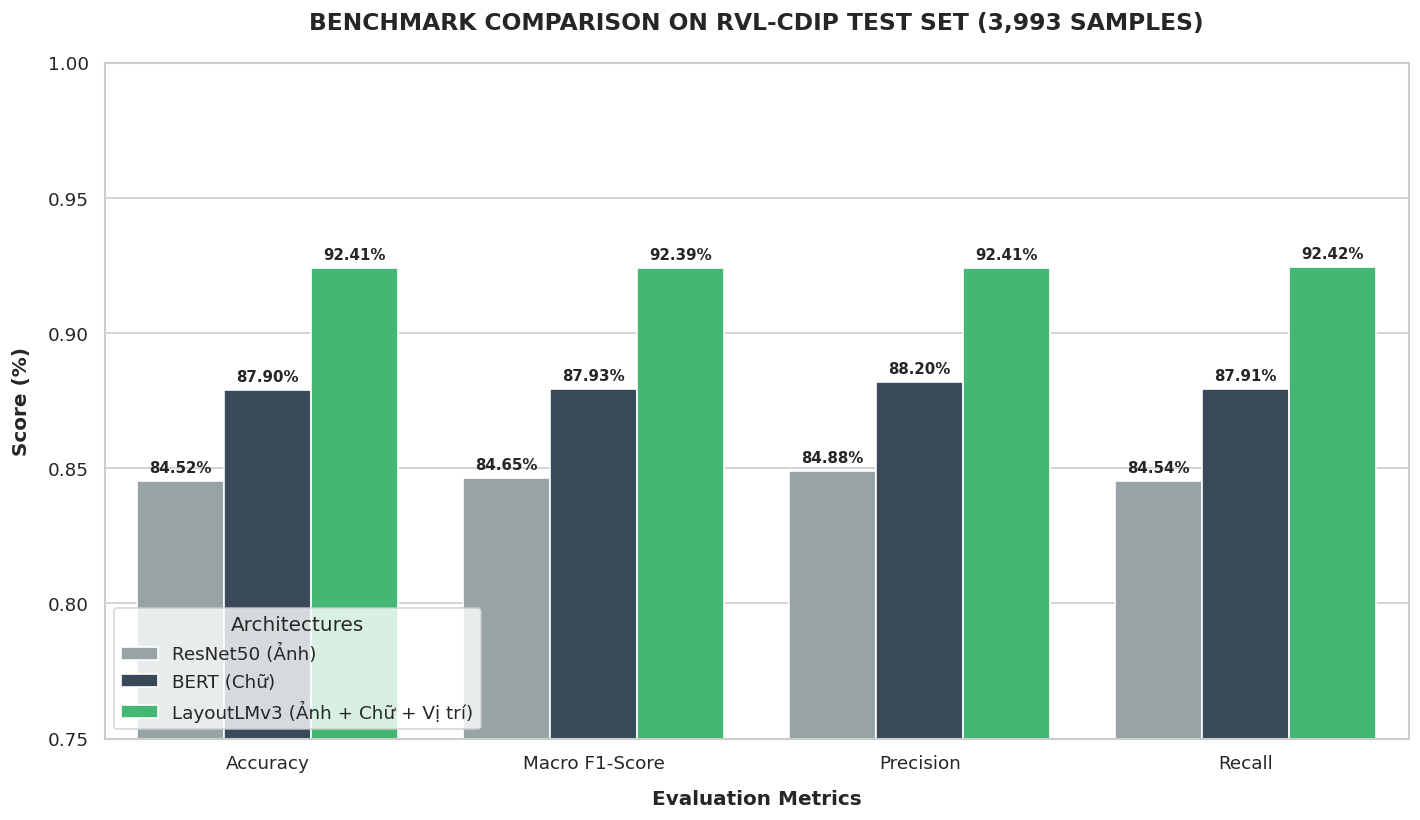

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Khởi tạo bảng dữ liệu tổng hợp từ kết quả thực tế
data = {
    "Model": ["ResNet50 (Ảnh)", "BERT (Chữ)", "LayoutLMv3 (Ảnh + Chữ + Vị trí)"],
    "Accuracy": [0.8452, 0.8790, 0.9241],
    "Macro F1-Score": [0.8465, 0.8793, 0.9239],
    "Precision": [0.8488, 0.8820, 0.9241],
    "Recall": [0.8454, 0.8791, 0.9242]
}

df_benchmark = pd.DataFrame(data)

# Chuyển đổi bảng dữ liệu sang dạng long-format để vẽ bằng Seaborn mượt hơn
df_melted = df_benchmark.melt(id_vars="Model", var_name="Metric", value_name="Score")

# 2. Tiến hành cấu hình vẽ biểu đồ cột nhóm
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Sử dụng bảng màu chuyên nghiệp để làm nổi bật sự vượt trội của LayoutLMv3
ax = sns.barplot(
    data=df_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette=["#95a5a6", "#34495e", "#2ecc71"] # Xám (Ảnh) - Xanh đậm (Chữ) - Xanh lá (Đa phương thức)
)

# Thêm con số cụ thể lên đầu mỗi cột chữ để thầy dễ nhìn điểm số
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f"{p.get_height()*100:.2f}%",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center',
            xytext=(0, 8),
            textcoords='offset points',
            fontsize=9, fontweight='bold'
        )

# Trang trí đồ thị
plt.title("BENCHMARK COMPARISON ON RVL-CDIP TEST SET (3,993 SAMPLES)", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Evaluation Metrics", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Score (%)", fontsize=12, fontweight='bold', labelpad=10)
plt.ylim(0.75, 1.0) # Thu hẹp khoảng cách từ 75% đến 100% để thấy rõ sự chênh lệch sức mạnh
plt.legend(title="Architectures", loc="lower left", frameon=True)
plt.tight_layout()

# Lưu biểu đồ thành ảnh độ phân giải cao đẩy sang Drive
os.makedirs('/content/drive/MyDrive/Document_AI/eval', exist_ok=True)
plt.savefig('/content/drive/MyDrive/Document_AI/eval/model_comparison_benchmark.png', dpi=300)
plt.show()

In [ ]:
import os
import json

DRIVE_ROOT_REAL = '/content/drive/MyDrive/LayoutLM_Project'
PROCESSED_DATA_REAL = f'{DRIVE_ROOT_REAL}/processed_data'
RESNET_TEST_IMG_DIR = '/content/resnet_images/resnet_images/test'
RESNET_TEST_JSONL = f'{PROCESSED_DATA_REAL}/resnet_test.jsonl'

print("🔍 --- BẮT ĐẦU KIỂM TRA HỆ THỐNG ĐƯỜNG DẪN --- \n")

# 1. Kiểm tra xem folder chứa ảnh thực tế có tồn tại không
if os.path.exists(RESNET_TEST_IMG_DIR):
    files = os.listdir(RESNET_TEST_IMG_DIR)
    print(f"✅ Thư mục ảnh tồn tại: {RESNET_TEST_IMG_DIR}")
    print(f"📊 Tổng số lượng file đếm được thực tế: {len(files)} file.")

    if len(files) > 0:
        print("\n📋 Danh sách 5 file ảnh thực tế đầu tiên kèm định dạng thật:")
        for f in files[:5]:
            print(f"   - {f}")
    else:
        print("❌ Thư mục trống rỗng! Lệnh giải nén bị lỗi hoặc sai đường dẫn gốc.")
else:
    print(f"❌ Thư mục không tồn tại: {RESNET_TEST_IMG_DIR}")

# 2. Kiểm tra xem file jsonl lưu thông tin như thế nào
print("\n--------------------------------------------------")
if os.path.exists(RESNET_TEST_JSONL):
    print(f"✅ Tìm thấy file dữ liệu JSONL: {RESNET_TEST_JSONL}")
    with open(RESNET_TEST_JSONL, encoding='utf-8') as f:
        for line in f:
            first_item = json.loads(line)
            print("\n📋 Cấu trúc dòng đầu tiên của file jsonl:")
            print(json.dumps(first_item, indent=4, ensure_ascii=False))
            break
else:
    print(f"❌ Không tìm thấy file JSONL tại: {RESNET_TEST_JSONL}")

🔍 --- BẮT ĐẦU KIỂM TRA HỆ THỐNG ĐƯỜNG DẪN --- 

✅ Thư mục ảnh tồn tại: /content/resnet_images/resnet_images/test
📊 Tổng số lượng file đếm được thực tế: 16 file.

📋 Danh sách 5 file ảnh thực tế đầu tiên kèm định dạng thật:
   - letter
   - file_folder
   - questionnaire
   - form
   - specification

--------------------------------------------------
✅ Tìm thấy file dữ liệu JSONL: /content/drive/MyDrive/LayoutLM_Project/processed_data/resnet_test.jsonl

📋 Cấu trúc dòng đầu tiên của file jsonl:
{
    "resnet_image_path": "test/advertisement/00001014.jpg",
    "label": "4"
}


In [ ]:
import json

BERT_TEST_JSONL = '/content/drive/MyDrive/LayoutLM_Project/processed_data/bert_test.jsonl'

print("🔍 --- KIỂM TRA HỆ THỐNG DỮ LIỆU BERT --- \n")

if os.path.exists(BERT_TEST_JSONL):
    print(f"✅ Tìm thấy file dữ liệu BERT JSONL: {BERT_TEST_JSONL}")
    with open(BERT_TEST_JSONL, encoding='utf-8') as f:
        for line in f:
            first_item = json.loads(line)
            print("\n📋 Cấu trúc dòng đầu tiên của file BERT test:")
            print(json.dumps(first_item, indent=4, ensure_ascii=False))
            break
else:
    print(f"❌ Không tìm thấy file BERT JSONL tại: {BERT_TEST_JSONL}")

🔍 --- KIỂM TRA HỆ THỐNG DỮ LIỆU BERT --- 

✅ Tìm thấy file dữ liệu BERT JSONL: /content/drive/MyDrive/LayoutLM_Project/processed_data/bert_test.jsonl

📋 Cấu trúc dòng đầu tiên của file BERT test:
{
    "text": "ARCHIVE LOCATION SHEET the number (Range)_0000/00 /- 0000/026 REPRESENTS (CHECK ONE): (X) OVERSIZE DOCUMENTS AUDIOTAPE(S) VIDEOTAPE(S) SLIDE(S) MICROFICHE OTHER (DESCRIBE) 5000",
    "label": "4"
}


In [ ]:
# Kiểm tra xem file zip nguồn trên Drive thực sự có dung lượng hay chỉ là file ảo 0 KB
!ls -lh /content/drive/MyDrive/LayoutLM_Project/processed_data/resnet_images_clean.zip

# Kiểm tra xem trong SSD Colab thực sự đã có file ảnh nào được giải nén ra chưa
!ls -l /content/resnet_images/resnet_images | head -10

-rw------- 1 root root 623M May 23 10:07 /content/drive/MyDrive/LayoutLM_Project/processed_data/resnet_images_clean.zip
total 12
drwxr-xr-x 18 root root 4096 May 23 10:06 test
drwxr-xr-x 18 root root 4096 May 23 10:05 train
drwxr-xr-x 18 root root 4096 May 23 10:06 val


In [ ]:
from transformers import LayoutLMv3ForSequenceClassification

print("🔄 Đang load chuẩn cấu trúc Sequence Classification từ checkpoint-11976...")

# 1. Load đúng kiến trúc phân loại văn bản của nhóm ông
model = LayoutLMv3ForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/Document_AI/checkpoints/outputs_tinh_chinh/checkpoint-11976"
)

# 2. Đồng bộ bộ nơ-ron sạch sẽ này vào biến Trainer hiện tại
trainer.model = model.to(trainer.args.device)

print("🎯 Cấu trúc đồng bộ hoàn hảo! Bắt đầu cày tập TEST độc lập...")

# 3. Chạy test trên đúng tập test_ds (3.993 mẫu)
test_results = trainer.evaluate(test_ds)

print("\n--- ✅ KẾT QUẢ TẬP TEST ĐỘC LẬP CHUẨN KHOA HỌC ---")
print(test_results)

🔄 Đang load chuẩn cấu trúc Sequence Classification từ checkpoint-11976...


Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

🎯 Cấu trúc đồng bộ hoàn hảo! Bắt đầu cày tập TEST độc lập...



--- ✅ KẾT QUẢ TẬP TEST ĐỘC LẬP CHUẨN KHOA HỌC ---
{'eval_loss': 0.42496636509895325, 'eval_model_preparation_time': 0.01, 'eval_accuracy': 0.9241, 'eval_f1': 0.9239, 'eval_precision': 0.9241, 'eval_recall': 0.9242, 'eval_runtime': 239.0978, 'eval_samples_per_second': 16.7, 'eval_steps_per_second': 2.091}


🔄 Đang thiết lập cấu hình rà soát lỗi toàn diện trên tập Test...
🎯 GPU đang rà soát ngầm toàn bộ tập Test để gom tất cả các mẫu lỗi...

--- ✅ KẾT QUẢ RÀ SOÁT HÀNG REAL ---
❌ Tổng số mẫu đoán sai thực tế trên tập Test: 303 / 3993
🎲 Đang chọn ngẫu nhiên 5 ảnh lỗi trong số 303 câu sai để in...


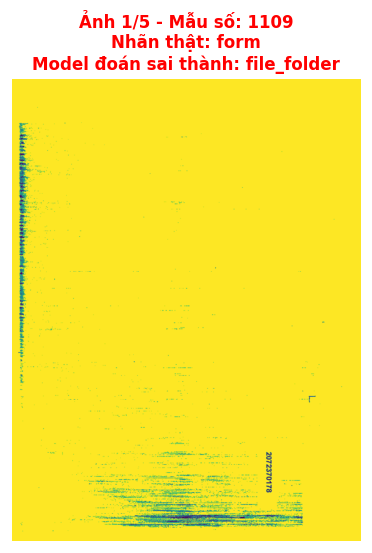

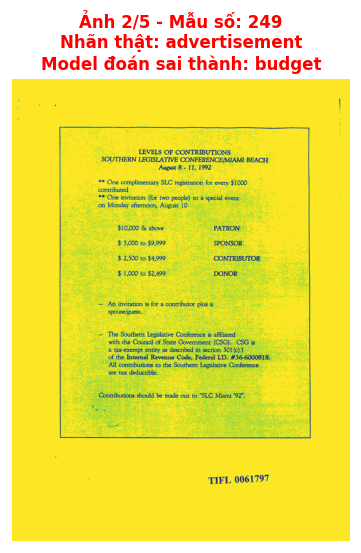

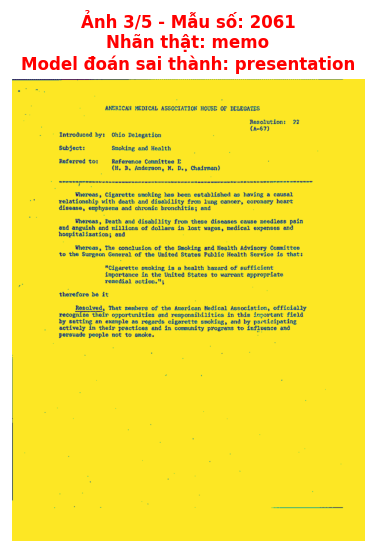

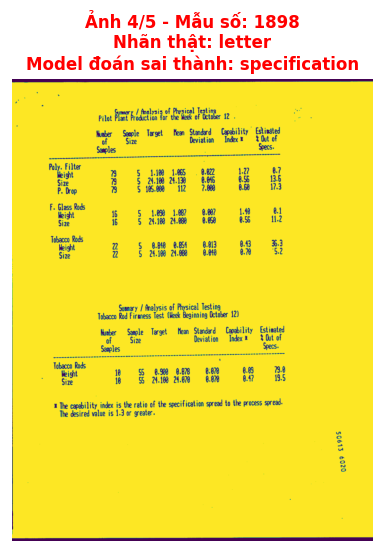

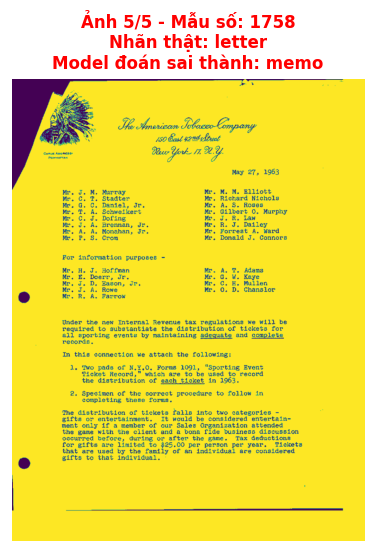


📸 Đã hiển thị xong 5 ảnh lỗi ngẫu nhiên 


In [ ]:
import torch
import random
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from datasets import Dataset

print("🔄 Đang thiết lập cấu hình rà soát lỗi toàn diện trên tập Test...")
model.eval()  # Chuyển mô hình sang chế độ dự đoán

# 1. Gọi biến test_ds_raw sạch để bốc ảnh gốc thô ban đầu
test_ds_raw = Dataset.from_generator(data_generator, gen_kwargs={"jsonl_path": TEST_JSONL})

# 2. Tạo bộ nạp dữ liệu cuốn chiếu để chống nghẽn RAM khi GPU chạy
eval_dataloader = DataLoader(test_ds, batch_size=16, collate_fn=trainer.data_collator)

wrong_samples = []

print("🎯 GPU đang rà soát ngầm toàn bộ tập Test để gom tất cả các mẫu lỗi...")

# Chạy ngầm quét sạch tập Test để gom danh sách câu sai thực tế
with torch.no_grad():
    for batch_idx, batch in enumerate(eval_dataloader):
        inputs = {k: v.to(model.device) for k, v in batch.items() if k != 'labels'}
        labels = batch['labels'].to(model.device)

        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=-1)

        wrong_mask = (preds != labels)
        wrong_indices_in_batch = wrong_mask.nonzero(as_tuple=True)[0]

        for idx in wrong_indices_in_batch:
            absolute_idx = batch_idx * eval_dataloader.batch_size + idx.item()

            true_idx = labels[idx].item()
            pred_idx = preds[idx].item()

            wrong_samples.append({
                'Index_Mẫu': absolute_idx,
                'True_Label_ID': true_idx,
                'Nhãn_Thật': ID2LABEL[true_idx],
                'Pred_Label_ID': pred_idx,
                'Model_Đoán_Sai': ID2LABEL[pred_idx]
            })

print(f"\n--- ✅ KẾT QUẢ RÀ SOÁT HÀNG REAL ---")
total_wrong = len(wrong_samples)
print(f"❌ Tổng số mẫu đoán sai thực tế trên tập Test: {total_wrong} / {len(test_ds)}")

# 3. Tiến hành bốc NGẪU NHIÊN 5 ảnh lỗi từ danh sách trên
num_images_to_show = min(5, total_wrong)

if num_images_to_show == 0:
    print("🎉 Quá đỉnh! Không có ảnh nào đoán sai để in ra cả.")
else:
    print(f"🎲 Đang chọn ngẫu nhiên {num_images_to_show} ảnh lỗi trong số {total_wrong} câu sai để in...")

    # Lấy ngẫu nhiên các mẫu lỗi
    random.seed(42)
    random_wrong_samples = random.sample(wrong_samples, num_images_to_show)

    # In trực tiếp 5 ảnh lỗi ngẫu nhiên lên màn hình
    for i, sample in enumerate(random_wrong_samples):
        abs_idx = sample['Index_Mẫu']
        true_name = sample['Nhãn_Thật']
        pred_name = sample['Model_Đoán_Sai']

        # Bốc đường dẫn ảnh thô từ biến raw
        sample_raw = test_ds_raw[abs_idx]
        img_path = sample_raw['image']

        # Vẽ đồ thị hiển thị ảnh
        plt.figure(figsize=(5, 5))
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(f"Ảnh {i+1}/5 - Mẫu số: {abs_idx}\nNhãn thật: {true_name}\nModel đoán sai thành: {pred_name}",
                  color='red', fontsize=10, fontweight='bold')
        plt.axis('off')
        plt.show()

print("\n📸 Đã hiển thị xong 5 ảnh lỗi ngẫu nhiên ")

🔄 Đang gom toàn bộ dự đoán thực tế trên tập Test để vẽ ma trận...


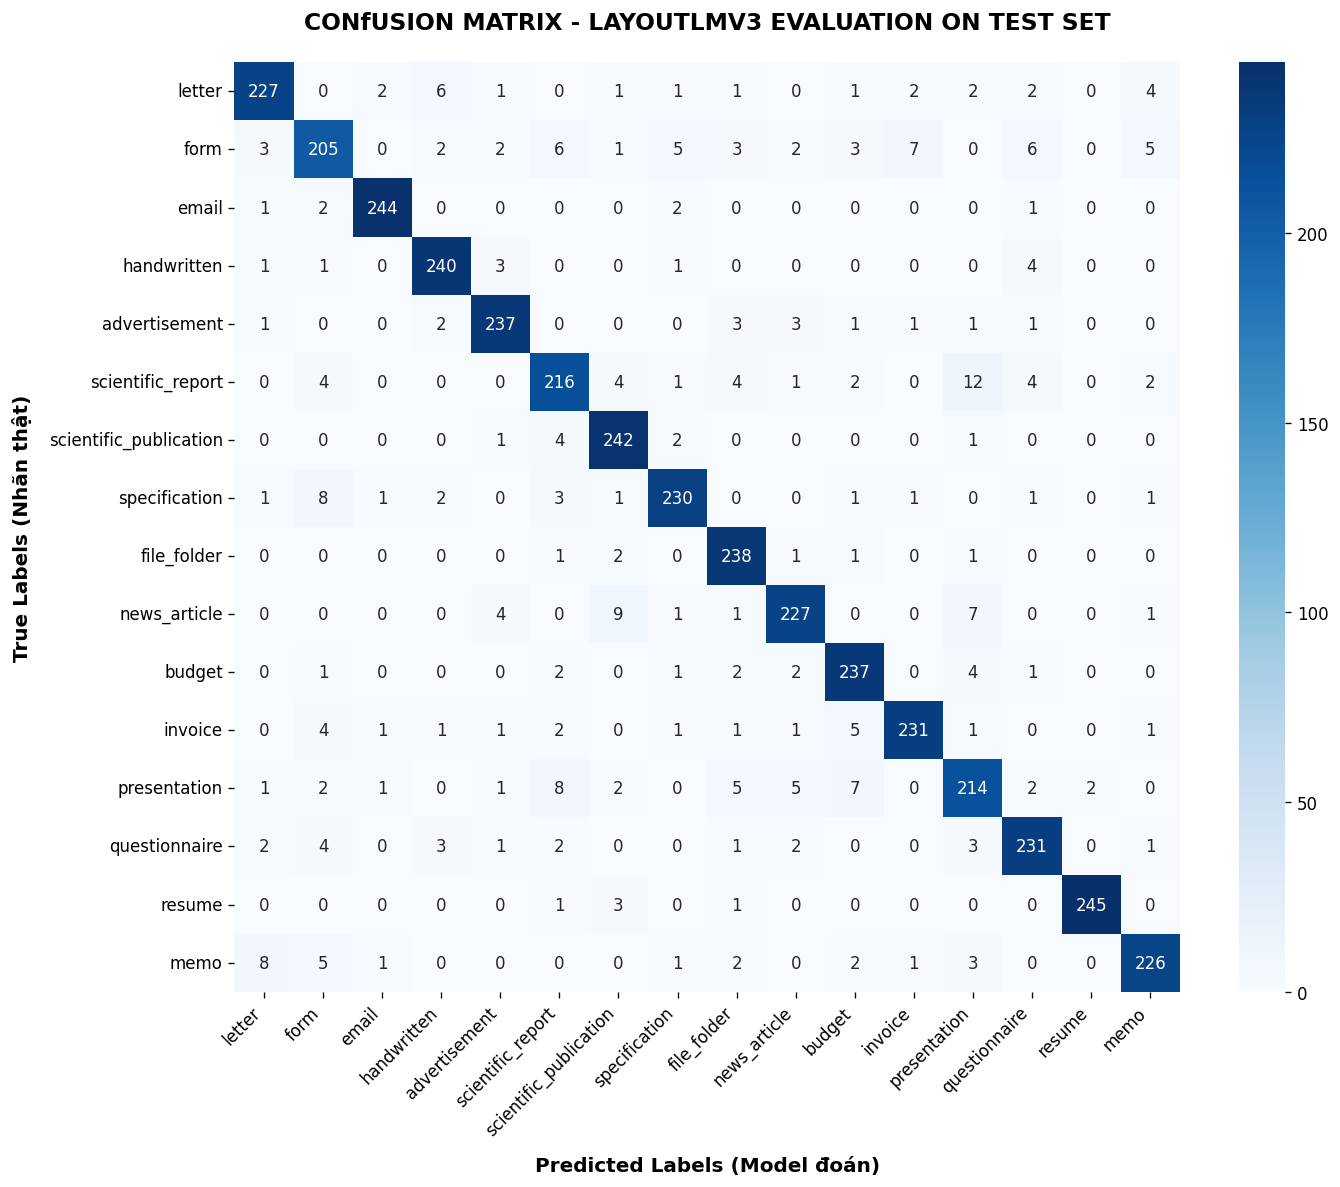

✅ Đã vẽ và lưu thành công ma trận nhầm lẫn!


In [ ]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader

print("🔄 Đang gom toàn bộ dự đoán thực tế trên tập Test để vẽ ma trận...")
model.eval()

eval_dataloader = DataLoader(test_ds, batch_size=16, collate_fn=trainer.data_collator)

all_preds = []
all_labels = []

# Tiến hành quét nhanh toàn bộ tập test để lấy nhãn real
with torch.no_grad():
    for batch in eval_dataloader:
        inputs = {k: v.to(model.device) for k, v in batch.items() if k != 'labels'}
        labels = batch['labels']

        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# 1. Tính toán ma trận nhầm lẫn bằng sklearn
cm = confusion_matrix(all_labels, all_preds)

# 2. Vẽ biểu đồ Heatmap bằng Seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,          # Hiện số lượng mẫu vào từng ô
    fmt='d',             # Định dạng số nguyên
    cmap='Blues',        # Tông màu xanh biển chuyên nghiệp
    xticklabels=LABEL_LIST,
    yticklabels=LABEL_LIST
)

plt.title('CONfUSION MATRIX - LAYOUTLMV3 EVALUATION ON TEST SET', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted Labels (Model đoán)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True Labels (Nhãn thật)', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Lưu biểu đồ thành file ảnh để ném vào slide
plt.savefig('/content/drive/MyDrive/Document_AI/eval/layoutlmv3_confusion_matrix.png', dpi=300)
plt.show()

print("✅ Đã vẽ và lưu thành công ma trận nhầm lẫn!")